# 含並行連結的網路（GoogLeNet）
:label:`sec_googlenet`

在2014年的ImageNet圖像識別挑戰賽中，一個名叫*GoogLeNet* :cite:`Szegedy.Liu.Jia.ea.2015`的網路架構大放異彩。
GoogLeNet吸收了NiN中串聯網路的思想，並在此基礎上做了改進。
這篇論文的一個重點是解決了什麼樣大小的卷積核最合適的問題。
畢竟，以前流行的網路使用小到$1 \times 1$，大到$11 \times 11$的卷積核。
本文的一個觀點是，有時使用不同大小的卷積核組合是有利的。
本節將介紹一個稍微簡化的GoogLeNet版本：我們省略了一些為穩定訓練而添加的特殊特性，現在有了更好的訓練方法，這些特性不是必要的。

## (**Inception塊**)

在GoogLeNet中，基本的卷積塊被稱為*Inception塊*（Inception block）。這很可能得名於電影《盜夢空間》（Inception），因為電影中有一句話“我們需要走得更深”（“We need to go deeper”）。

![Inception塊的架構。](../img/inception.svg)
:label:`fig_inception`

如 :numref:`fig_inception`所示，Inception塊由四條並行路徑組成。
前三條路徑使用窗口大小為$1\times 1$、$3\times 3$和$5\times 5$的卷積層，從不同空間大小中提取信息。
中間的兩條路徑在輸入上執行$1\times 1$卷積，以減少通道數，從而降低模型的複雜性。
第四條路徑使用$3\times 3$最大彙集層，然後使用$1\times 1$卷積層來改變通道數。
這四條路徑都使用合適的填充來使輸入與輸出的高和寬一致，最後我們將每條路徑的輸出在通道維度上連結，並構成Inception塊的輸出。在Inception塊中，通常調整的超參數是每層輸出通道數。


In [1]:
import torch
from torch import nn
from torch.nn import functional as F


class Inception(nn.Module):
    # c1--c4是每條路徑的輸出通道數
    def __init__(self, in_channels, c1, c2, c3, c4, **kwargs):
        super(Inception, self).__init__(**kwargs)
        # 線路1，單1x1卷積層
        self.p1_1 = nn.Conv2d(in_channels, c1, kernel_size=1)
        # 線路2，1x1卷積層後接3x3卷積層
        self.p2_1 = nn.Conv2d(in_channels, c2[0], kernel_size=1)
        self.p2_2 = nn.Conv2d(c2[0], c2[1], kernel_size=3, padding=1)
        # 線路3，1x1卷積層後接5x5卷積層
        self.p3_1 = nn.Conv2d(in_channels, c3[0], kernel_size=1)
        self.p3_2 = nn.Conv2d(c3[0], c3[1], kernel_size=5, padding=2)
        # 線路4，3x3最大彙集層後接1x1卷積層
        self.p4_1 = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
        self.p4_2 = nn.Conv2d(in_channels, c4, kernel_size=1)

    def forward(self, x):
        p1 = F.relu(self.p1_1(x))
        p2 = F.relu(self.p2_2(F.relu(self.p2_1(x))))
        p3 = F.relu(self.p3_2(F.relu(self.p3_1(x))))
        p4 = F.relu(self.p4_2(self.p4_1(x)))
        # 在通道維度上連結輸出
        return torch.cat((p1, p2, p3, p4), dim=1)

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


那麼為什麼GoogLeNet這個網路如此有效呢？
首先我們考慮一下濾波器（filter）的組合，它們可以用各種濾波器尺寸探索圖像，這意味著不同大小的濾波器可以有效地識別不同範圍的圖像細節。
同時，我們可以為不同的濾波器分配不同數量的參數。

## (**GoogLeNet模型**)

如 :numref:`fig_inception_full`所示，GoogLeNet一共使用9個Inception塊和全局平均彙集層的堆疊來生成其估計值。Inception塊之間的最大彙集層可降低維度。
第一個模塊類似於AlexNet和LeNet，Inception塊的組合從VGG繼承，全局平均彙集層避免了在最後使用全連接層。

![GoogLeNet架構。](../img/inception-full.svg)
:label:`fig_inception_full`

現在，我們逐一實現GoogLeNet的每個模塊。第一個模塊使用64個通道、$7\times 7$卷積層。


In [2]:
b1 = nn.Sequential(nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
                   nn.ReLU(),
                   nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

第二個模塊使用兩個卷積層：第一個卷積層是64個通道、$1\times 1$卷積層；第二個卷積層使用將通道數量增加三倍的$3\times 3$卷積層。
這對應於Inception塊中的第二條路徑。


In [3]:
b2 = nn.Sequential(nn.Conv2d(64, 64, kernel_size=1),
                   nn.ReLU(),
                   nn.Conv2d(64, 192, kernel_size=3, padding=1),
                   nn.ReLU(),
                   nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

第三個模塊串聯兩個完整的Inception塊。
第一個Inception塊的輸出通道數為$64+128+32+32=256$，四條路徑之間的輸出通道數量比為$64:128:32:32=2:4:1:1$。
第二個和第三個路徑首先將輸入通道的數量分別減少到$96/192=1/2$和$16/192=1/12$，然後連接第二個卷積層。第二個Inception塊的輸出通道數增加到$128+192+96+64=480$，四條路徑之間的輸出通道數量比為$128:192:96:64 = 4:6:3:2$。
第二條和第三條路徑首先將輸入通道的數量分別減少到$128/256=1/2$和$32/256=1/8$。


In [4]:
b3 = nn.Sequential(Inception(192, 64, (96, 128), (16, 32), 32),
                   Inception(256, 128, (128, 192), (32, 96), 64),
                   nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

第四模塊更加複雜，
它串聯了5個Inception塊，其輸出通道數分別是$192+208+48+64=512$、$160+224+64+64=512$、$128+256+64+64=512$、$112+288+64+64=528$和$256+320+128+128=832$。
這些路徑的通道數分配和第三模塊中的類似，首先是含$3×3$卷積層的第二條路徑輸出最多通道，其次是僅含$1×1$卷積層的第一條路徑，之後是含$5×5$卷積層的第三條路徑和含$3×3$最大彙集層的第四條路徑。
其中第二、第三條路徑都會先按比例減小通道數。
這些比例在各個Inception塊中都略有不同。


In [5]:
b4 = nn.Sequential(Inception(480, 192, (96, 208), (16, 48), 64),
                   Inception(512, 160, (112, 224), (24, 64), 64),
                   Inception(512, 128, (128, 256), (24, 64), 64),
                   Inception(512, 112, (144, 288), (32, 64), 64),
                   Inception(528, 256, (160, 320), (32, 128), 128),
                   nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

第五模塊包含輸出通道數為$256+320+128+128=832$和$384+384+128+128=1024$的兩個Inception塊。
其中每條路徑通道數的分配思路和第三、第四模塊中的一致，只是在具體數值上有所不同。
需要注意的是，第五模塊的後面緊跟輸出層，該模塊同NiN一樣使用全局平均彙集層，將每個通道的高和寬變成1。
最後我們將輸出變成二維數組，再接上一個輸出個數為標籤類別數的全連接層。


In [6]:
b5 = nn.Sequential(Inception(832, 256, (160, 320), (32, 128), 128),
                   Inception(832, 384, (192, 384), (48, 128), 128),
                   nn.AdaptiveAvgPool2d((1,1)),
                   nn.Flatten())

net = nn.Sequential(b1, b2, b3, b4, b5, nn.Linear(1024, 10))

GoogLeNet模型的計算複雜，而且不如VGG那樣便於修改通道數。
[**為了使Fashion-MNIST上的訓練短小精悍，我們將輸入的高和寬從224降到96**]，這簡化了計算。下面演示各個模塊輸出的形狀變化。


In [7]:
X = torch.rand(size=(1, 1, 96, 96))
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 64, 24, 24])
Sequential output shape:	 torch.Size([1, 192, 12, 12])
Sequential output shape:	 torch.Size([1, 480, 6, 6])
Sequential output shape:	 torch.Size([1, 832, 3, 3])
Sequential output shape:	 torch.Size([1, 1024])
Linear output shape:	 torch.Size([1, 10])


[W NNPACK.cpp:64] Could not initialize NNPACK! Reason: Unsupported hardware.


## [**訓練模型**]

和以前一樣，我們使用Fashion-MNIST數據集來訓練我們的模型。在訓練之前，我們將圖片轉換為$96 \times 96$分辨率。


Using device: mps


Epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Epoch 1/10: 100%|██████████| 469/469 [03:47<00:00,  2.06it/s, loss=0.018, acc=9.84%] 


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


...

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Epoch 10/10: 100%|██████████| 469/469 [03:39<00:00,  2.13it/s, loss=0.018, acc=9.71%]


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


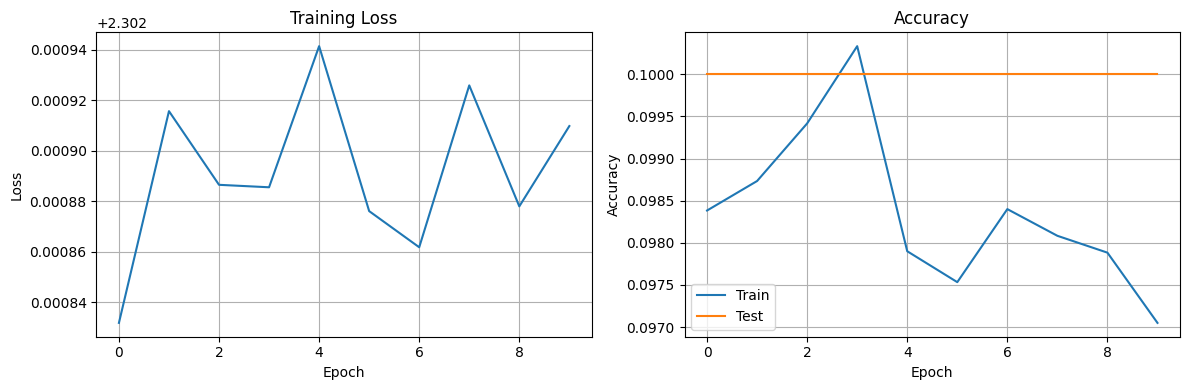


Final Results:
Final Loss: 2.3029
Final Train Accuracy: 0.0970
Final Test Accuracy: 0.1000
Average Epoch Time: 231.52s


In [8]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm
import matplotlib.pyplot as plt
import time

class Inception(nn.Module):
    def __init__(self, in_channels, c1, c2, c3, c4):
        super(Inception, self).__init__()
        # 線路1：單1x1卷積層
        self.p1_1 = nn.Conv2d(in_channels, c1, kernel_size=1)
        
        # 線路2：1x1卷積層後接3x3卷積層
        self.p2_1 = nn.Conv2d(in_channels, c2[0], kernel_size=1)
        self.p2_2 = nn.Conv2d(c2[0], c2[1], kernel_size=3, padding=1)
        
        # 線路3：1x1卷積層後接5x5卷積層
        self.p3_1 = nn.Conv2d(in_channels, c3[0], kernel_size=1)
        self.p3_2 = nn.Conv2d(c3[0], c3[1], kernel_size=5, padding=2)
        
        # 線路4：3x3最大池化層後接1x1卷積層
        self.p4_1 = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
        self.p4_2 = nn.Conv2d(in_channels, c4, kernel_size=1)

    def forward(self, x):
        p1 = torch.relu(self.p1_1(x))
        p2 = torch.relu(self.p2_2(torch.relu(self.p2_1(x))))
        p3 = torch.relu(self.p3_2(torch.relu(self.p3_1(x))))
        p4 = torch.relu(self.p4_2(self.p4_1(x)))
        return torch.cat((p1, p2, p3, p4), dim=1)

class GoogLeNet(nn.Module):
    def __init__(self, num_classes=10):
        super(GoogLeNet, self).__init__()
        self.b1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        
        self.b2 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        
        self.b3 = nn.Sequential(
            Inception(192, 64, (96, 128), (16, 32), 32),
            Inception(256, 128, (128, 192), (32, 96), 64),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        
        self.b4 = nn.Sequential(
            Inception(480, 192, (96, 208), (16, 48), 64),
            Inception(512, 160, (112, 224), (24, 64), 64),
            Inception(512, 128, (128, 256), (24, 64), 64),
            Inception(512, 112, (144, 288), (32, 64), 64),
            Inception(528, 256, (160, 320), (32, 128), 128),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        
        self.b5 = nn.Sequential(
            Inception(832, 256, (160, 320), (32, 128), 128),
            Inception(832, 384, (192, 384), (48, 128), 128),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten()
        )
        
        self.linear = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.b1(x)
        x = self.b2(x)
        x = self.b3(x)
        x = self.b4(x)
        x = self.b5(x)
        x = self.linear(x)
        return x

def load_fashion_mnist(batch_size, resize=96):
    """加載Fashion-MNIST數據集"""
    transform = transforms.Compose([
        transforms.Resize(resize),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    
    train_dataset = datasets.FashionMNIST(
        root='./data', train=True, download=True, transform=transform
    )
    test_dataset = datasets.FashionMNIST(
        root='./data', train=False, download=True, transform=transform
    )
    
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, num_workers=2
    )
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False, num_workers=2
    )
    
    return train_loader, test_loader

def train_googlenet(net, train_loader, test_loader, num_epochs, lr, device):
    """訓練GoogLeNet模型"""
    net = net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_acc': [],
        'epoch_times': []
    }
    
    for epoch in range(num_epochs):
        epoch_start = time.time()
        net.train()
        train_loss = 0
        correct_train = 0
        total_train = 0
        
        # 訓練階段
        train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
        for inputs, targets in train_bar:
            inputs, targets = inputs.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = net(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total_train += targets.size(0)
            correct_train += predicted.eq(targets).sum().item()
            
            # 更新進度條
            train_bar.set_postfix({
                'loss': f'{train_loss/total_train:.3f}',
                'acc': f'{100.*correct_train/total_train:.2f}%'
            })
        
        # 測試階段
        net.eval()
        correct_test = 0
        total_test = 0
        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = net(inputs)
                _, predicted = outputs.max(1)
                total_test += targets.size(0)
                correct_test += predicted.eq(targets).sum().item()
        
        # 記錄結果
        epoch_time = time.time() - epoch_start
        epoch_loss = train_loss / len(train_loader)
        train_acc = correct_train / total_train
        test_acc = correct_test / total_test
        
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        history['epoch_times'].append(epoch_time)
        
        print(f'\nEpoch {epoch+1}/{num_epochs}:')
        print(f'Loss: {epoch_loss:.4f}')
        print(f'Train Acc: {train_acc:.4f}')
        print(f'Test Acc: {test_acc:.4f}')
        print(f'Time: {epoch_time:.2f}s')
        print('-' * 50)
    
    # 繪製訓練曲線
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'])
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train')
    plt.plot(history['test_acc'], label='Test')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return history

if __name__ == "__main__":
    # 設置參數
    batch_size = 128
    num_epochs = 10
    lr = 0.1
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # 加載數據
    train_loader, test_loader = load_fashion_mnist(batch_size, resize=96)
    
    # 創建模型
    net = GoogLeNet()
    
    # 訓練模型
    history = train_googlenet(net, train_loader, test_loader, num_epochs, lr, device)
    
    # 打印最終結果
    print("\nFinal Results:")
    print(f"Final Loss: {history['train_loss'][-1]:.4f}")
    print(f"Final Train Accuracy: {history['train_acc'][-1]:.4f}")
    print(f"Final Test Accuracy: {history['test_acc'][-1]:.4f}")
    print(f"Average Epoch Time: {sum(history['epoch_times'])/len(history['epoch_times']):.2f}s")

## 小結

* Inception塊相當於一個有4條路徑的子網路。它通過不同窗口形狀的卷積層和最大彙集層來並行抽取信息，並使用$1×1$卷積層減少每像素級別上的通道維數從而降低模型複雜度。
*  GoogLeNet將多個設計精細的Inception塊與其他層（卷積層、全連接層）串聯起來。其中Inception塊的通道數分配之比是在ImageNet數據集上通過大量的實驗得來的。
* GoogLeNet和它的後繼者們一度是ImageNet上最有效的模型之一：它以較低的計算複雜度提供了類似的測試精度。

## 練習

1. GoogLeNet有一些後續版本。嘗試實現並運行它們，然後觀察實驗結果。這些後續版本包括：
    * 添加批量規範化層 :cite:`Ioffe.Szegedy.2015`（batch normalization），在 :numref:`sec_batch_norm`中將介紹；
    * 對Inception模塊進行調整 :cite:`Szegedy.Vanhoucke.Ioffe.ea.2016`；
    * 使用標籤平滑（label smoothing）進行模型正則化 :cite:`Szegedy.Vanhoucke.Ioffe.ea.2016`；
    * 加入殘差連接 :cite:`Szegedy.Ioffe.Vanhoucke.ea.2017`。（ :numref:`sec_resnet`將介紹）。
1. 使用GoogLeNet的最小圖像大小是多少？
1. 將AlexNet、VGG和NiN的模型參數大小與GoogLeNet進行比較。後兩個網路架構是如何顯著減少模型參數大小的？


[Discussions](https://discuss.d2l.ai/t/1871)
